In [66]:
import numpy as np
import matplotlib.pyplot as plt
import torch as pt
import OptimalBattery.util as ut
import OptimalBattery.estimate as et


In [67]:
n_tasks = 5
n_parcels = 5
n_vox = 10000

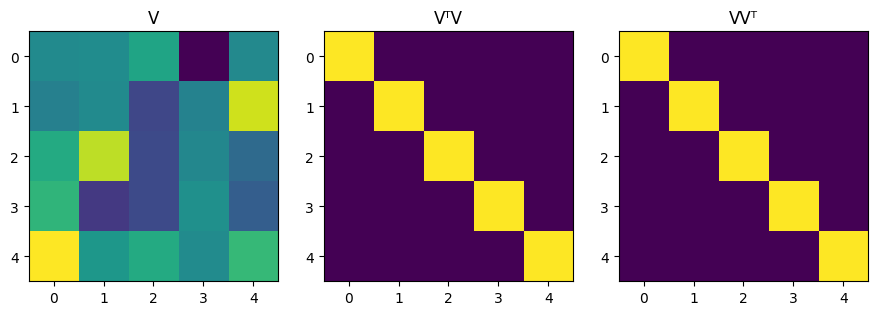

2003.0


In [68]:
rng= np.random.default_rng()
V_lib = rng.normal(0,1,(n_tasks,n_parcels))
V_lib,_ = np.linalg.qr(V_lib)
VtV = V_lib.T @ V_lib
VVt = V_lib @ V_lib.T

mats = [V_lib,  VtV, VVt]
names = ['V', 'VᵀV', 'VVᵀ']

# plot
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
for ax, M, name in zip(axs, mats, names):
    ax.imshow(M)
    ax.set_title(name)
plt.tight_layout()
plt.show()


device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
noise_data = rng.normal(0, 1, (n_tasks, n_vox))
noise_data = pt.tensor(noise_data, dtype=pt.float64, device=device)


# noise_data = ut.center_matrix(noise_data,axis=0)
noise_data = ut.normalize_matrix(noise_data,axis=0)

# V_lib = ut.center_matrix(V_lib,axis=0)
V_lib = ut.normalize_matrix(V_lib,axis=0)
V_lib = pt.tensor(V_lib, dtype=pt.float64, device=device)

U_hat = et.estimate_Us(noise_data, V_lib, method='correlation', hard=True)
predicted_size = U_hat[0,0, :].sum().item()
print(predicted_size)



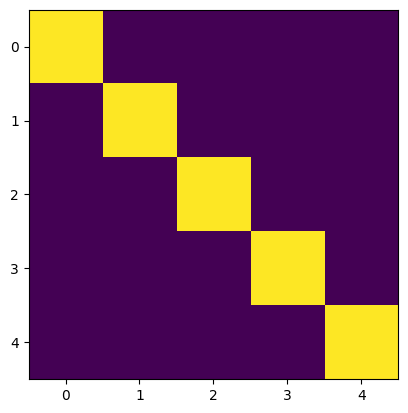

In [69]:
# make an iid 5x5 matrix
A = rng.normal(0,1,(5,5))
A = np.eye(5)
plt.imshow(A)


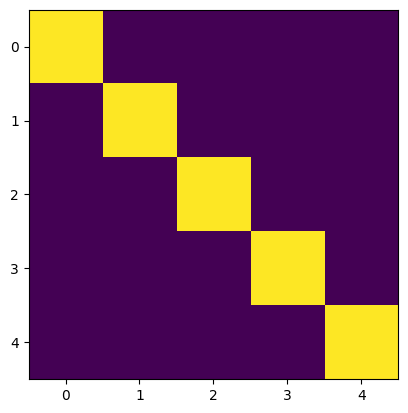

In [70]:
plt.imshow(A @ A.T)


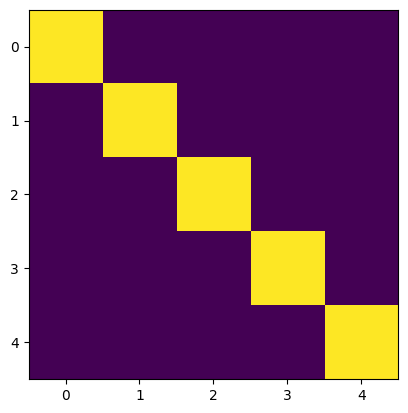

In [71]:
plt.imshow(A.T @ A)

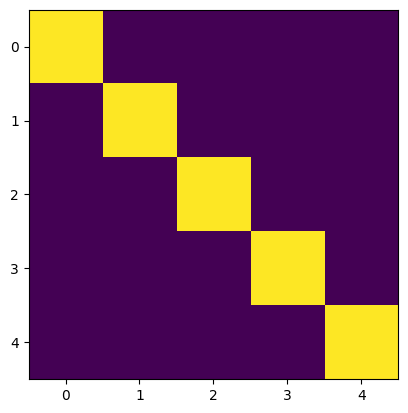

In [72]:
import numpy as np

# Start with 5x3 matrix (tasks x regions)
V = np.eye(5, 5)  # simple "identity-like" example

# Generate a random 5x5 rotation matrix (via QR decomposition)
A = np.random.normal(size=(5, 5))
Q, _ = np.linalg.qr(A)  # Q is orthogonal (Q.T @ Q = I)
plt.imshow(Q @ Q.T) 




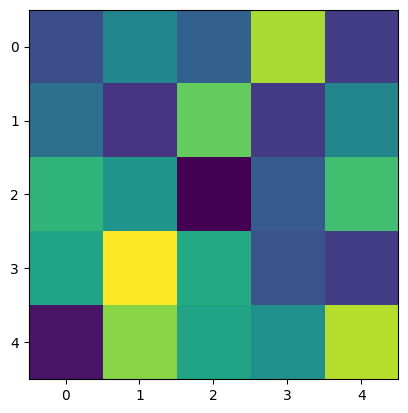

In [73]:
# # Rotate the task space
V_rot = Q @ V
plt.imshow(V_rot )

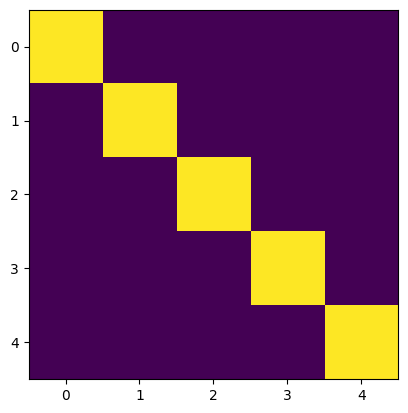

In [74]:
plt.imshow(V_rot @ V_rot.T)

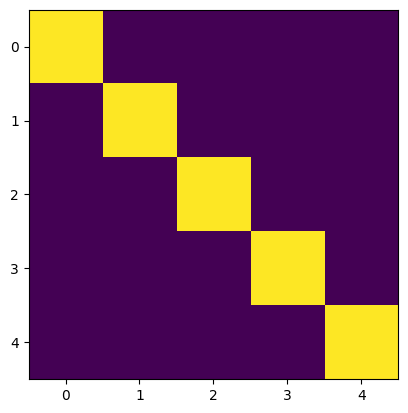

In [75]:
plt.imshow(V_rot.T @ V_rot)